In [1]:
import glaes as gl
import geokit as gk
import numpy as np
import matplotlib.pyplot as plt

# Initialization

<Axes: >

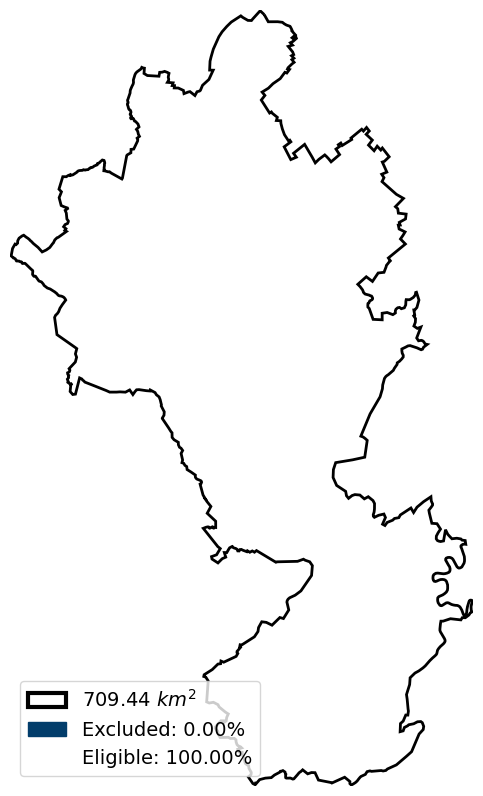

In [2]:
# CREATING AN EXLCUSION CALCULATOR OBJECT - where clause

regionPath = gl._test_data_["aachenShapefile.shp"]
ec = gl.ExclusionCalculator(regionPath, srs=3035)
ec.draw()

In [3]:
regionPath = gl._test_data_["aachenShapefile.shp"]
df = gk.vector.extractFeatures(regionPath)
df["geom"].iloc[0].GetEnvelope() # xmin max ymin max

(5.974861621856746, 6.419306755066032, 50.494369506836165, 50.95013427734369)

<Axes: >

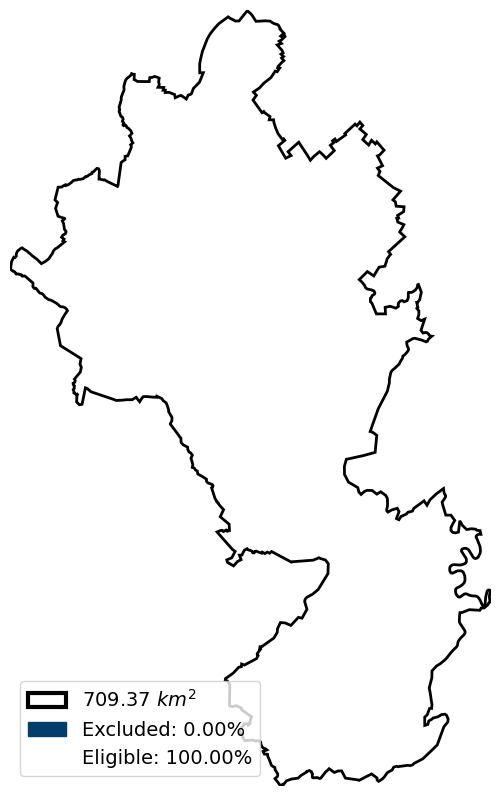

In [4]:
## CONSIDERED
# CREATING AN EXLCUSION CALCULATOR OBJECT - with srs and pixelRes
# ?01 What exacly is the difference between srs 3035 and LAEA ???
ec = gl.ExclusionCalculator(regionPath, srs="LAEA", pixelRes=50)
ec.draw()

In [5]:
ec.region.mask.shape
print( type(ec.region) )
print( type(ec.region.extent) )

<class 'geokit.core.regionmask.RegionMask'>
<class 'geokit.core.extent.Extent'>


In [6]:
ec.region.extent

xMin: -15700.000000
xMax: 15750.000000
yMin: -25350.000000
yMax: 25400.000000
srs: PROJCS["unknown",GEOGCS["unknown",DATUM["Unknown based on GRS80 ellipsoid using towgs84=0,0,0,0,0,0,0",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],TOWGS84[0,0,0,0,0,0,0]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",50.7222518920899],PARAMETER["longitude_of_center",6.19708418846139],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

xMin: -20700.000000
xMax: 20750.000000
yMin: -30350.000000
yMax: 30400.000000
srs: PROJCS["unknown",GEOGCS["unknown",DATUM["Unknown based on GRS80 ellipsoid using towgs84=0,0,0,0,0,0,0",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],TOWGS84[0,0,0,0,0,0,0]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",50.7222518920899],PARAMETER["longitude_of_center",6.19708418846139],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

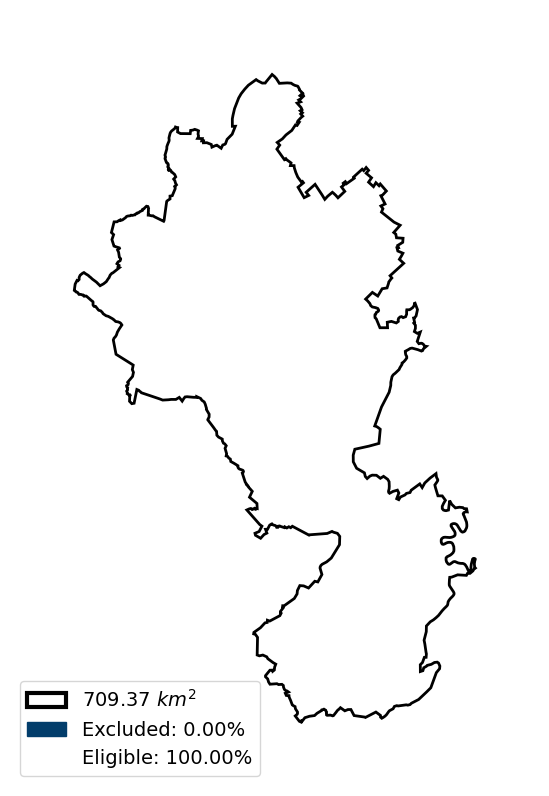

In [7]:
# ?02 what does the where statement exactly do ??? 
# ?03 what does padExtent do ??? => extents the regions boundaries. some of those buffer zones might extend beyond your region boundary.
# If there’s no padding, those 3 km around the edge would be cut off.
# With padding, you have enough raster around your region to fully calculate those edge effects. Imagine a road lies 1 km outside your regaion boundary but you want an exlusion
# of 3 km around roads => correclty 2 km within your region had to be excluded, what only happens if you consider roads outside your boundaries with padExtent within 1km.
# ! include example wih padExtent = 0 vs padExtent = 5000

ec = gl.ExclusionCalculator(
    region=regionPath, 
    # where="HASC_1='DE.NW'", 
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000
    )
ec.draw()
ec.region.extent

In [8]:
ec.region.mask.shape

(1215, 829)

<Axes: >

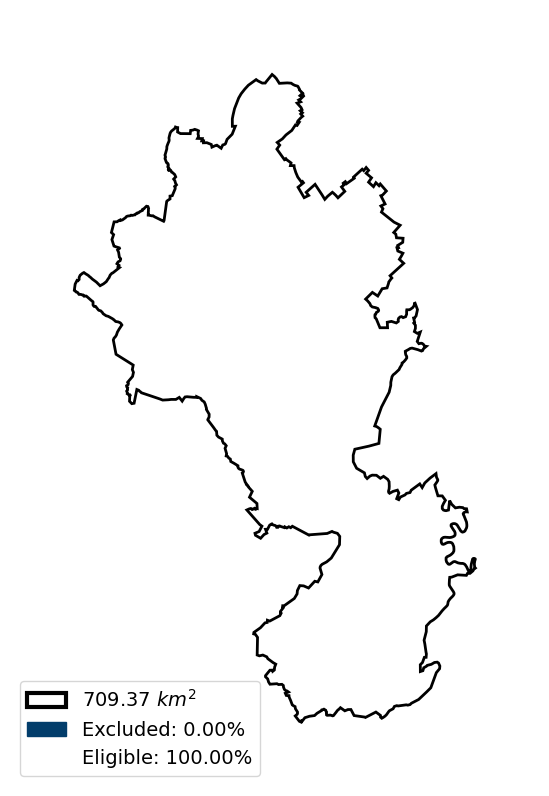

In [9]:
# CREATING AN EXLCUSION CALCULATOR OBJECT - with initialValue
# ? Using initialValue to use existing exlusion maps as starting point?
ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000,
    initialValue=True)
ec.draw()

# Exclude Raster

<Axes: >

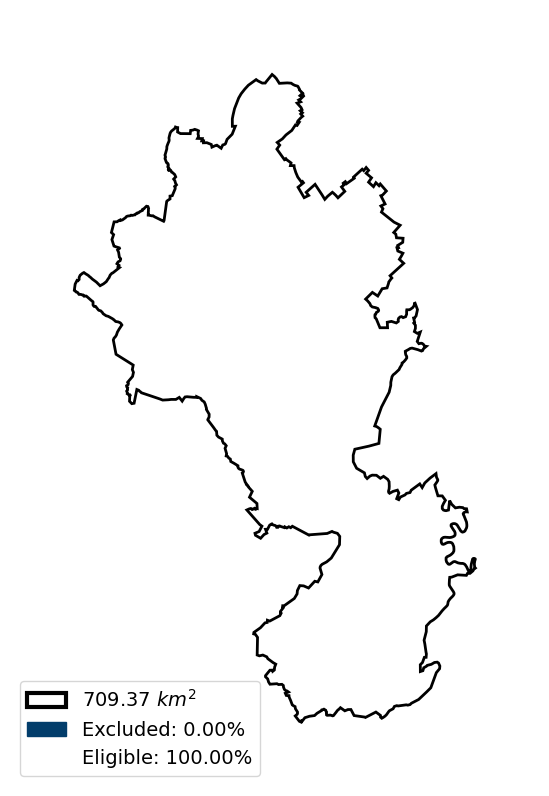

In [10]:
def make_new_ec(**kwargs):
    
    ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        **kwargs)
    return ec
ec = make_new_ec()
ec.draw()

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 233.453125 MB


<Axes: >

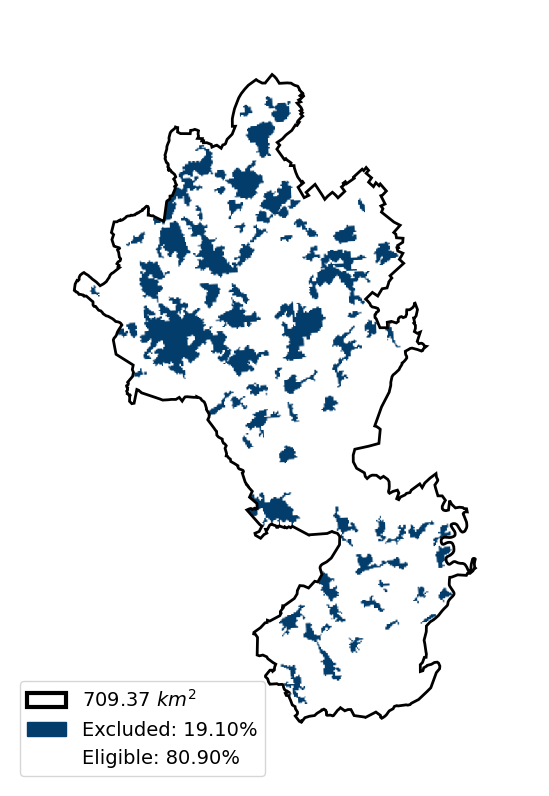

In [11]:
# Exclude Raster - Simple CLC with specific value
# !! Describe what CLC is more exactly and what numbers refer to which land use types !
clc_path = gl._test_data_["clc-aachen_clipped.tif"]
ec.excludeRasterType(source=clc_path, value=(1,2))

ec.draw()

Memory useage during calc: 242.328125 MB
Memory useage during calc: 244.24609375 MB


<Axes: >

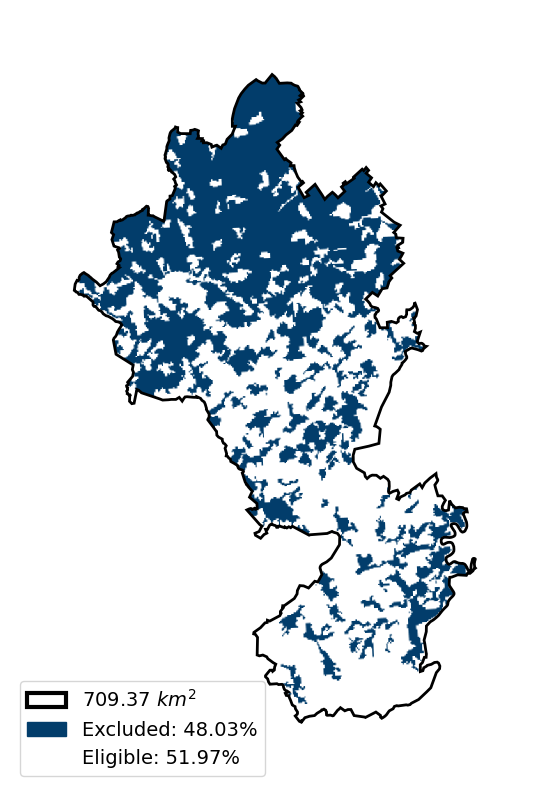

In [12]:
# Exclude Raster - Simple CLC with a range of values
# ??? Full list of CLC numbers?

# Simple way
ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value=(1,2))

# More complex way
# 1-2 -> settlement areas
# 12 -> industrial areas
# 21-23 -> forests
ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]")

ec.draw()

Memory useage during calc: 253.5546875 MB


<Axes: >

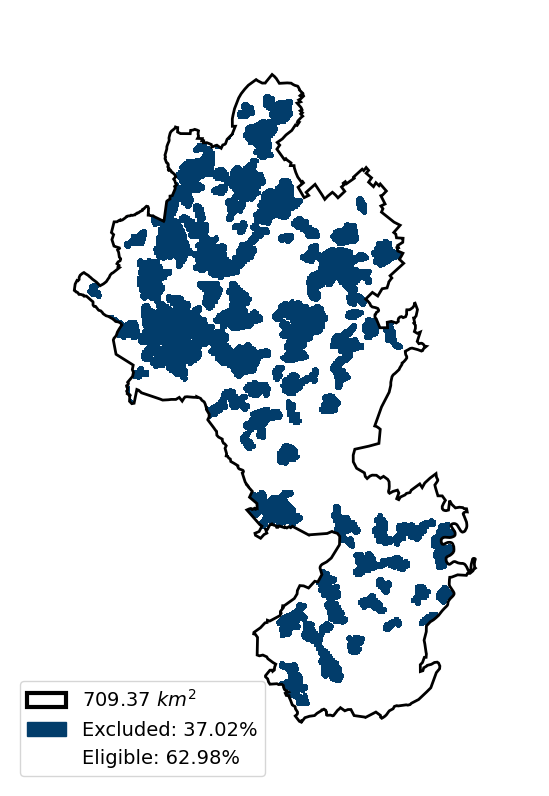

In [13]:

# Exclude Raster - with Buffer

ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value=(1,2), buffer=200)

ec.draw()

100.0
Memory useage during calc: 259.90625 MB
20.44800157886019
Memory useage during calc: 257.9296875 MB
21.004243186760128


<Axes: >

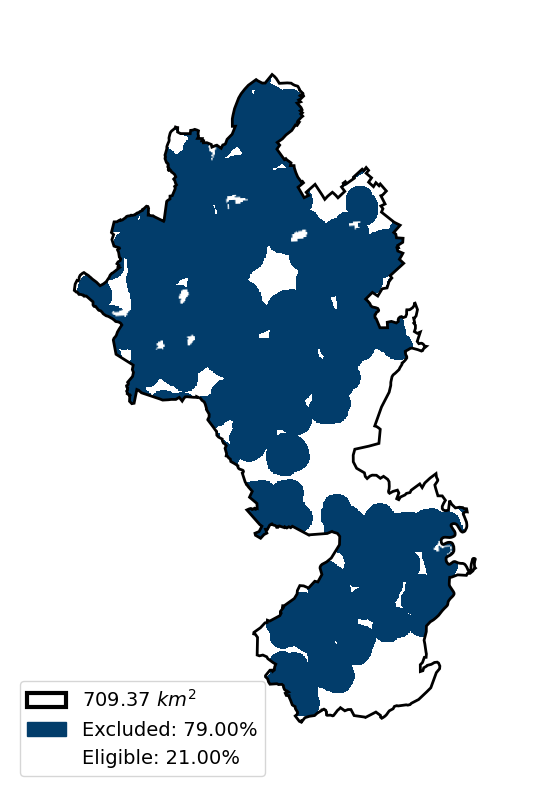

In [14]:

# Exclude Raster - mode Include
# GOTCHYA!! Ordering matters a lot!!!!

# ? Mode include? Whats happening here, which order has to be kept? Create small exmaple featuring Exclusion calculator as inclusion calculator using invert option ("only forests are eligible")

ec = make_new_ec()
print(ec.percentAvailable)



ec.excludeRasterType(source=clc_path, value=(1,2), buffer=1000)
print(ec.percentAvailable)

ec.excludeRasterType(source=clc_path, value=11, mode="include")
print(ec.percentAvailable)



ec.draw()

Memory useage during calc: 273.2109375 MB


<Axes: >

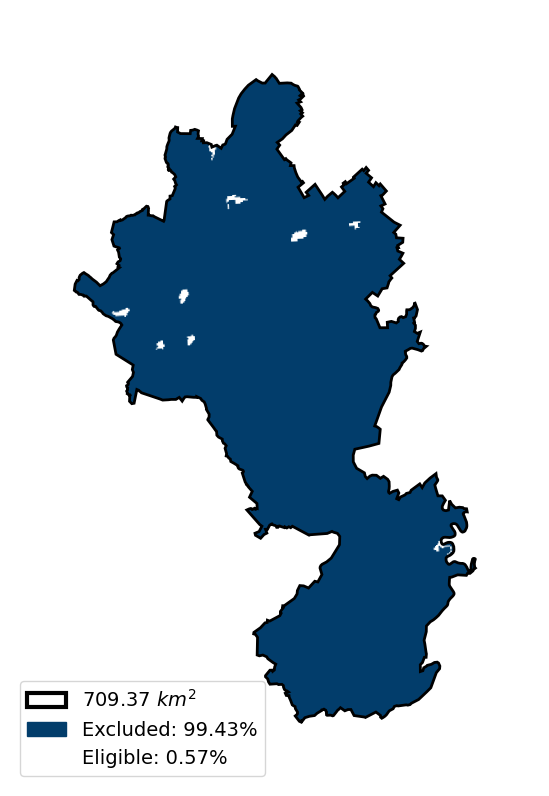

In [15]:

# Exclude Raster - mode Include version 2
# [JM] here: "only 11 eligible" => Inclusion Calculator. 
# Generally: ! Create easy basic workflow exmpl using default exlusion. ! 2nd explain that areas can be filter in different ways, or flipped, explain and show etra features like inlude mode in 3rd example
# differentiate: initial Value: the starting mask (100% not/eligible), invert (flip result), exlusion/ inclusion mode. Principally you can work with white or blacklist so to say.

ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=False)

ec.excludeRasterType(source=clc_path, value=11, mode="include")

ec.draw()

Memory useage during calc: 281.546875 MB


<Axes: >

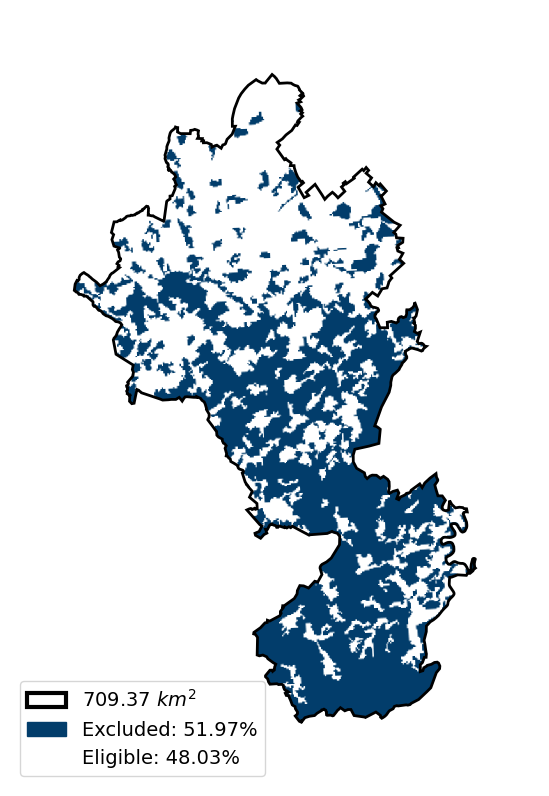

In [16]:

# Exclude Raster - mode Invert
# More complex way
# 1-2 -> settlement areas
# 12 -> industrial areas
# 21-23 -> forests
ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]", invert=True)

ec.draw()

In [17]:

# Exclude Raster - resolutionDiv

In [18]:

# Exclude Raster - prewarp

In [19]:

# Exclude Raster - resampleAlg -> "Down sampling": near,bilinear,cubic  "upsampling":average,mode,max,min

In [20]:
# Exclude Raster - DEM Mosaic

# [JM]: How can I reproduce the heatmap, is there .hgt files available in the current GLAES directory?
#   
ec = make_new_ec()
dem_raster = ec.region.extent.rasterMosaic(r"C:\Users\j.mutke\Desktop\GLAES_Github\glaes\glaes\test\data\*.hgt")

<class 'osgeo.gdal.Dataset'>


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x000001A89D229C60>, cbar=<matplotlib.colorbar.Colorbar object at 0x000001A89D2528F0>)

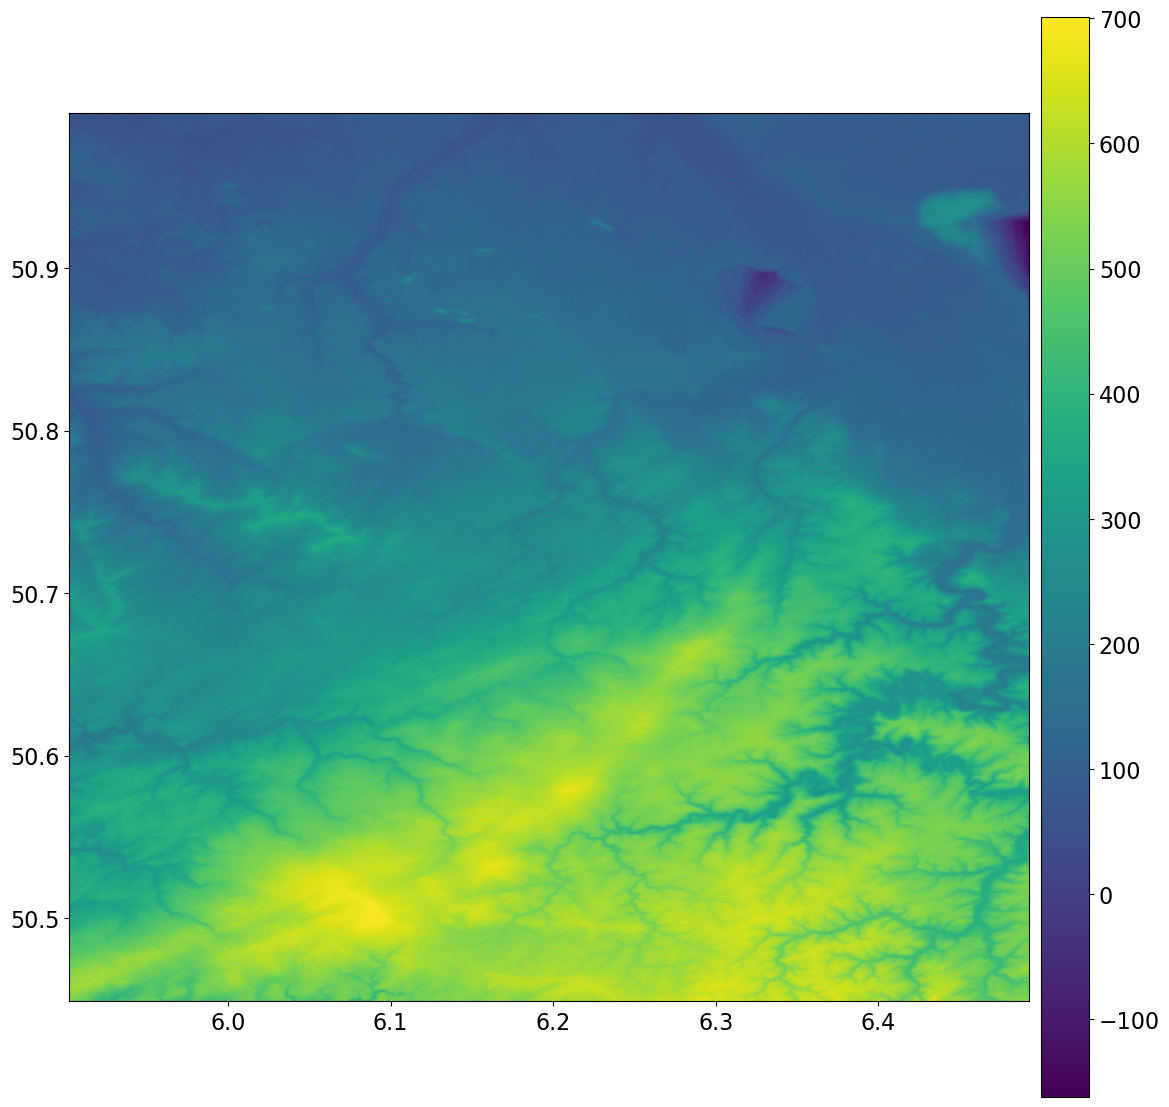

In [21]:
print(type(dem_raster))
gk.drawRaster(dem_raster)

Memory useage during calc: 352.19921875 MB


<Axes: >

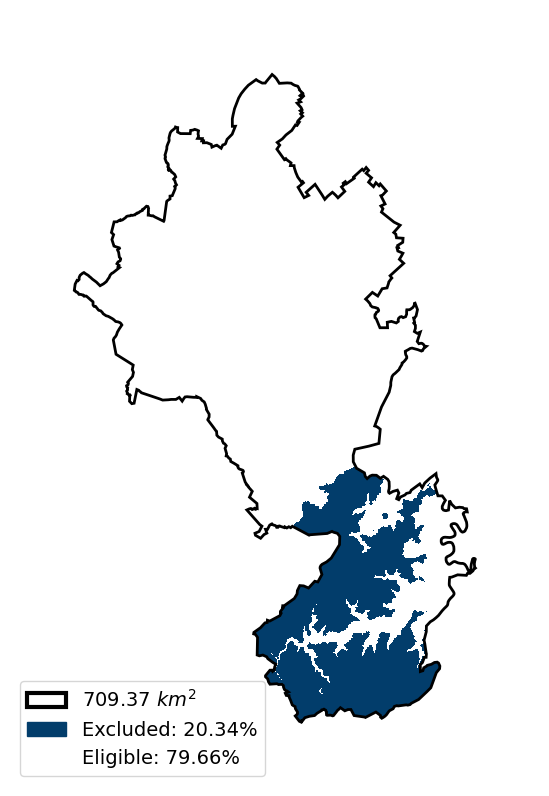

In [22]:
ec.excludeRasterType(dem_raster, value="(500-]", resampleAlg="mode")
ec.draw()

Memory useage during calc: 372.51953125 MB


<Axes: >

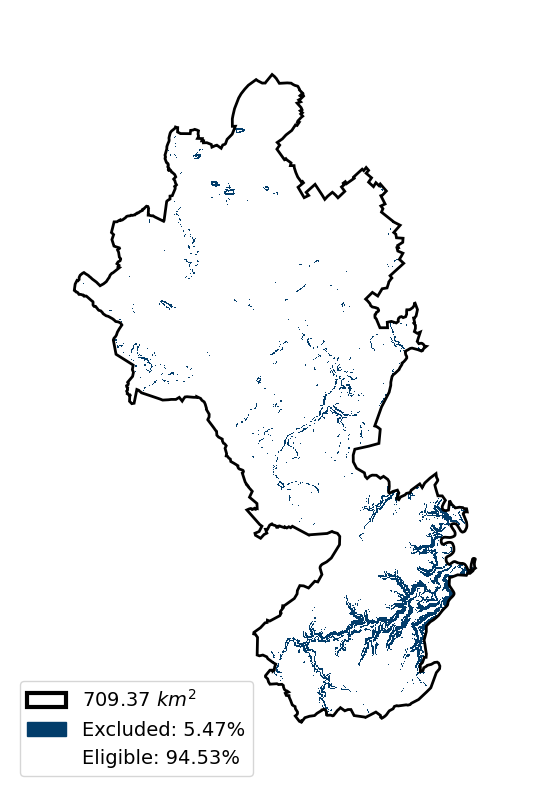

In [23]:
# Exclude Raster - DEM Gradient Mosaic
dem_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM"),
    processor=lambda x: np.degrees(np.arctan(x))
)

ec = make_new_ec()
ec.excludeRasterType(dem_gradiate_raster, value=(15, None), resampleAlg="mode")

ec.draw()

Memory useage during calc: 411.76953125 MB


<Axes: >

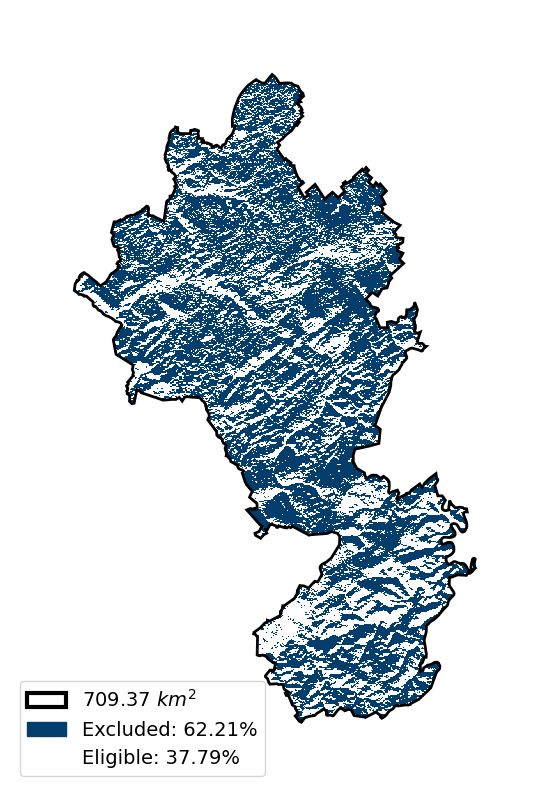

In [24]:
# Exclude Raster - DEM Gradient Mosaic - North-South
dem_ns_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM",
            mode="north-south"),
    processor=lambda matrix: np.degrees(np.arctan(matrix))
)

ec = make_new_ec()
ec.excludeRasterType(dem_ns_gradiate_raster, value=(0, None), resampleAlg="mode")

ec.draw()

# Exclude Vector

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


<Axes: >

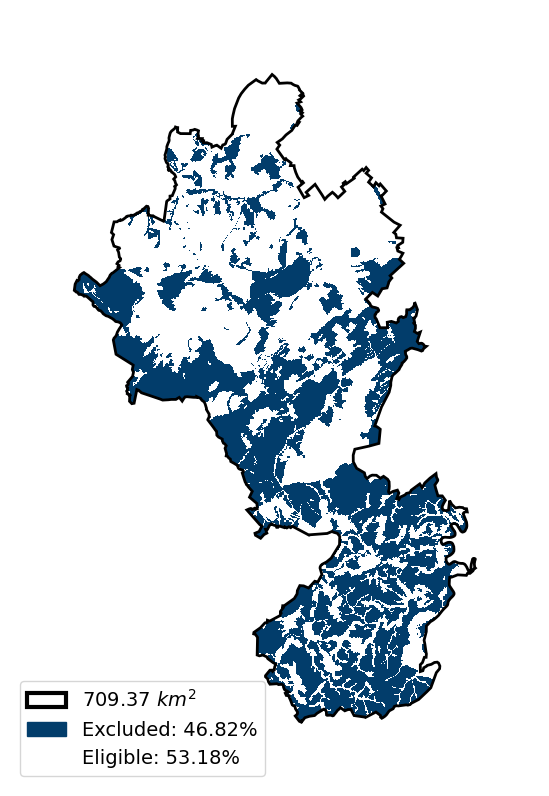

In [25]:
# Exclude Vector - Simple source w/ where clause
# [JM]: WDPA_Jul2020-shapefile-polygons.shp missing. Found similar file under CAESER: "/shared_data/2023_gears/geography/protected_areas/wdpa/WDPA_Feb2020-shapefile-points.shp", yet 4 GB

# ec = make_new_ec()
# ec.excludeVectorType(
#     source=r"C:\Users\s.ryberg\FZJ\data\geography\protected_areas\protected_planet\WDPA_Jul2020-shapefile2\WDPA_Jul2020-shapefile-polygons.shp",
#     where="IUCN_CAT='V'",
# )

# [JM] alternative try
ec = make_new_ec()
ec.excludeVectorType(
    source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_Feb2020-shapefile-polygons.shp",
    where="IUCN_CAT='V'",
)

ec.draw()

In [26]:
!mkdir intermediate_files

A subdirectory or file intermediate_files already exists.


c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 432.875 MB


Applying intermediate exclusion file: ./intermediate_files/wdpa_V.tif


<Axes: >

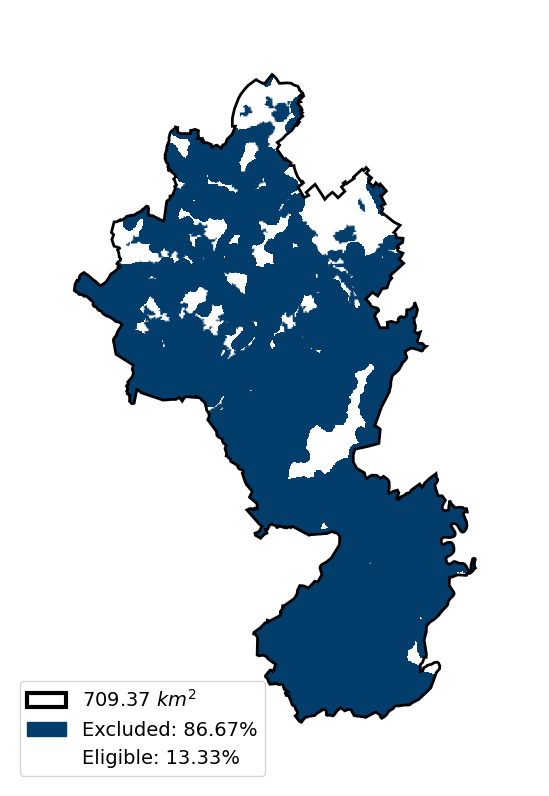

In [27]:
# Exclude Vector - Simple source w/ where clause and intermediate

ec = make_new_ec()

ec.excludeRasterType(clc_path, value=(1,2))

ec.excludeVectorType(
    source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_Feb2020-shapefile-polygons.shp",
    where="IUCN_CAT='V'",
    buffer=400,
    intermediate="./intermediate_files/wdpa_V.tif"
)

# ec.excludeVectorType(
#     source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_Feb2020-shapefile-polygons.shp",
#     where="IUCN_CAT='V'",
#     resolutionDiv=20,
# )


ec.draw()

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x000001A89FAC95A0>, cbar=<matplotlib.colorbar.Colorbar object at 0x000001A89FAC9960>)

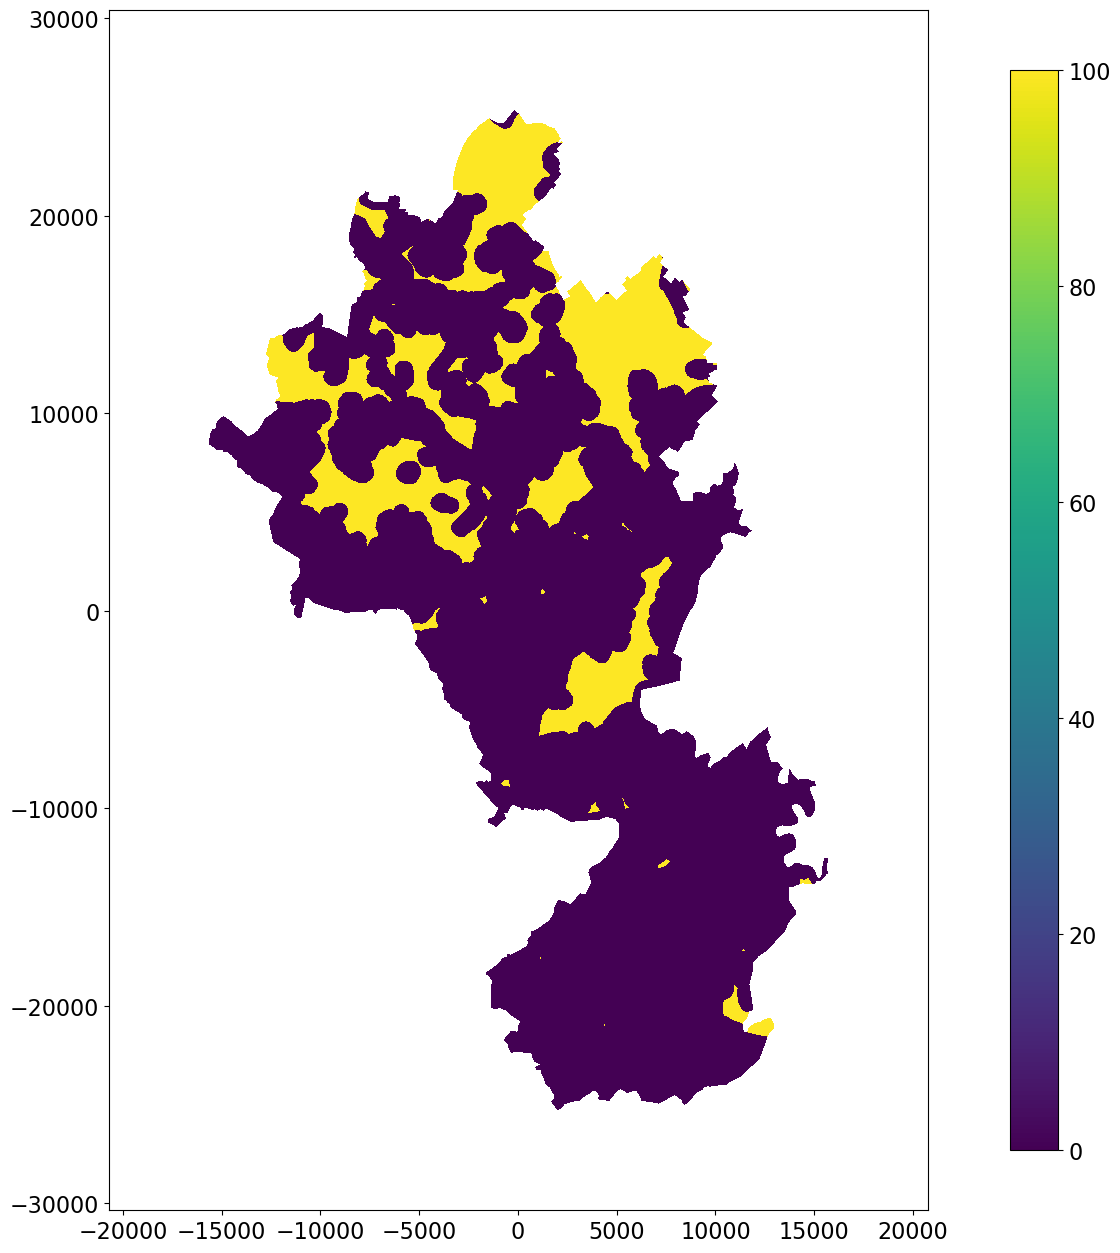

In [28]:
gk.drawRaster("./intermediate_files/wdpa_V.tif")

In [29]:

# Exclude Vector - Simple source w/ where clause & buffer

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


<Axes: >

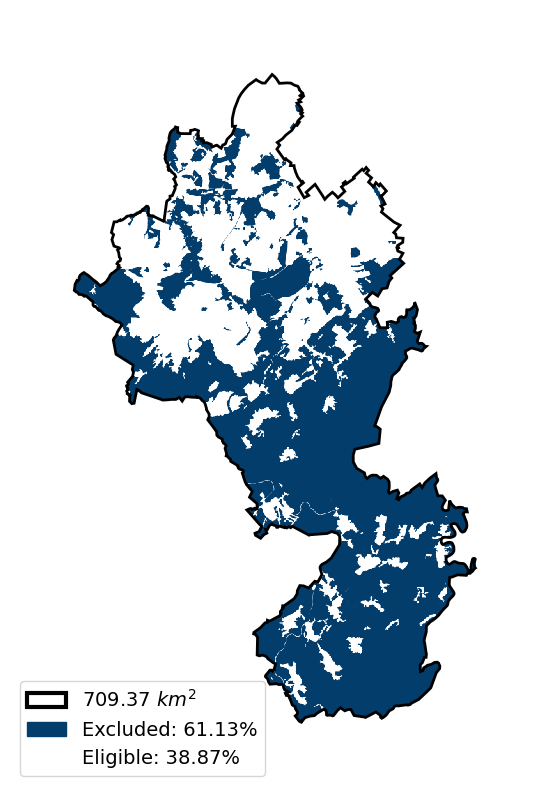

In [30]:
# Exclude Vector - resolutionDiv

ec = make_new_ec()
ec.excludeVectorType(
    source=r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/Examples/data/WDPA_Feb2020-shapefile-polygons.shp",
    resolutionDiv=8,
    # forceMaskShape=True
)

ec.draw()

In [31]:
ec.save("test_resolution_div_8.tif")

PermissionError: Writing permission error for path: 

# Save results

In [ ]:
ec.save?

Signature: ec.save(output, threshold=None, **kwargs)
Docstring:
Save the current availability matrix to a raster file

Output will be a byte-valued raster with the following convention:
    0     -> unavailable
    1..99 -> Semi-available
    100   -> fully eligibile
    255   -> "no data" (out of region)

Parameters:
-----------
output : str
    The path of the output raster file
    * Must end in ".tif"

threshold : float; optional
    The acceptable threshold indicating an available pixel
    * Use this to process the availability matrix before saving it (will
      save a little bit of space)

kwargs:
    * All keyword arguments are passed on to a call to
      geokit.RegionMask.createRaster
    * Most notably:
        - 'dtype' is used to define the data type of the resulting raster
        - 'overwrite' is used to force overwrite an existing file
File:      c:\users\s.ryberg\fzj\workdir\2034_glaes_workshop\glaes\glaes\core\exclusioncalculator.py
Type:      method


In [ ]:
ec.save("exclusion_result.tif", threshold=90)

'exclusion_result.tif'

# Prior Datasets

In [41]:
from glaes import Priors
Priors.loadDirectory(r"C:\Users\s.ryberg\FZJ\data\geography\glaes_priors")

In [42]:
# After moving files into the glaes/data/priors directory...
# from glaes import Priors

import glaes as gl
import geokit as gk
import numpy as np

In [ ]:
# What are the prior datasets

In [ ]:
# How to install Priors

In [43]:
# How to access priors
roads_prior = gl.Priors['roads_main_proximity']

GlaesError: No priors have been installed. Use gl.setPriorDirectory( <path> ) or else place the files directly in the default prior data directory (c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\glaes\data\priors)

In [ ]:
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

C:\Users\s.ryberg\AppData\Local\Continuum\anaconda3\envs\glaes\lib\site-packages\geokit\core\raster.py:1559: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(h, cax=cbax, **tmp)


AxHands(ax=<matplotlib.axes._axes.Axes object at 0x000002611DD9DC10>, handles=<matplotlib.image.AxesImage object at 0x000002611FC74430>, cbar=<matplotlib.colorbar.Colorbar object at 0x000002611FC8E370>)

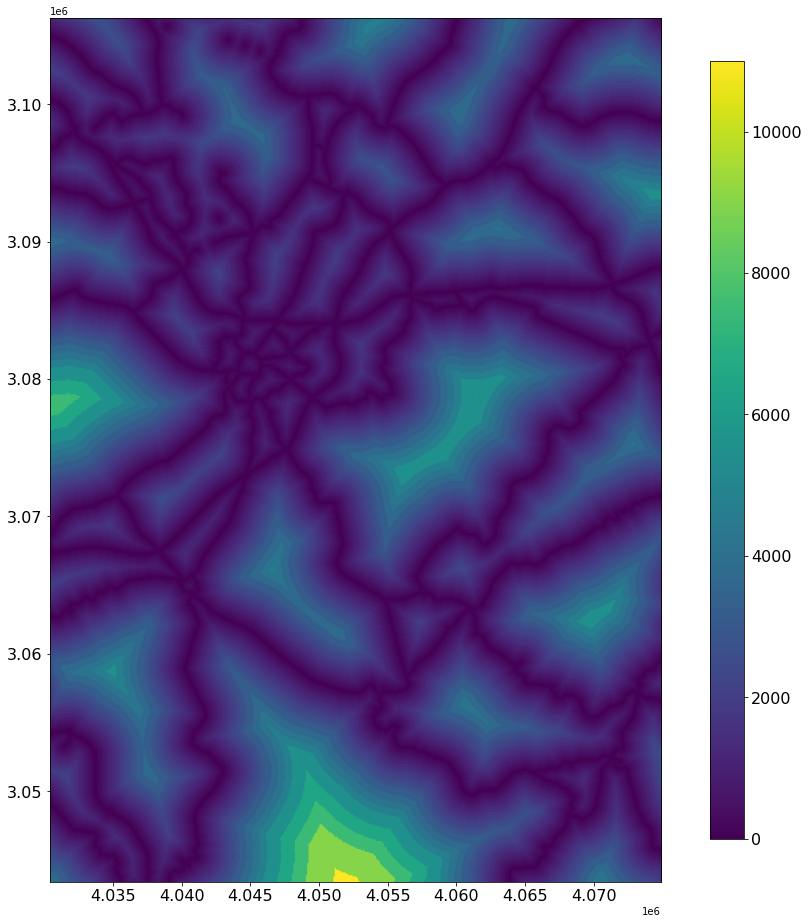

In [ ]:
gk.drawRaster(roads_prior.generateRaster(ec.region.extent))

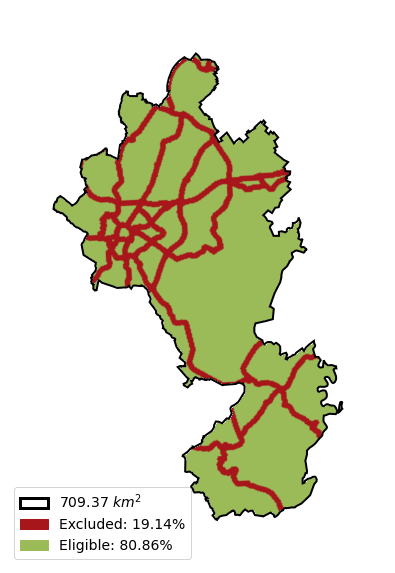

In [ ]:
# How to use priors
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

ec.("roads_main_proximity", value=(0,300))

ec.draw()

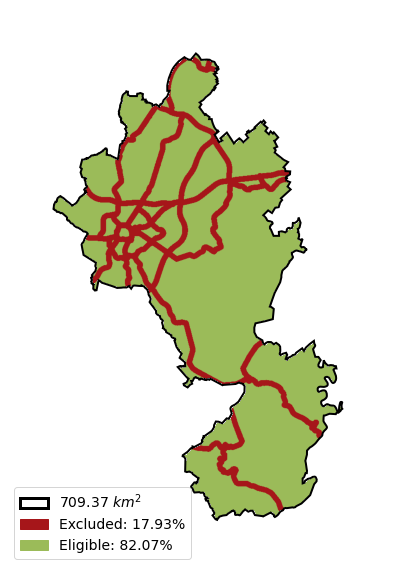

In [ ]:
# Showcase of how the prior dataset is faster!
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

ec.excludeVectorType(r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_roads_free_1.shp", 
                     where="fclass='primary' OR fclass='motorway' OR fclass='trunk'",
                     buffer=300)

ec.draw()

In [ ]:
gl.Priors.listKeys

access_distance
agriculture_arable_proximity
agriculture_heterogeneous_proximity
agriculture_pasture_proximity
agriculture_permanent_crop_proximity
agriculture_proximity
airfield_proximity
airport_proximity
camping_proximity
connection_distance
dni_threshold
elevation_threshold
ghi_threshold
industrial_proximity
lake_proximity
leisure_proximity
mining_proximity
ocean_proximity
power_line_proximity
protected_biosphere_proximity
protected_bird_proximity
protected_habitat_proximity
protected_landscape_proximity
protected_natural_monument_proximity
protected_park_proximity
protected_reserve_proximity
protected_wilderness_proximity
railway_proximity
river_proximity
roads_main_proximity
roads_proximity
roads_secondary_proximity
sand_proximity
settlement_proximity
settlement_urban_proximity
slope_north_facing_threshold
slope_threshold
touristic_proximity
waterbody_proximity
wetland_proximity
windspeed_100m_threshold
windspeed_50m_threshold
woodland_coniferous_proximity
woodland_deciduous_prox

In [ ]:
# How to produce a prior dataset
# !mkdir prior_temp
indications = []
for buffer_value in [0,50,100,250,500,1000,2000,5000]:
    print(buffer_value)
    indications.append( 
        ec.region.indicateValues(
            source=clc_path,
            value=(1,2),
            buffer=buffer_value
        )
    )


0
50
100
250
500
1000
2000
5000


In [ ]:
prior_data = np.full_like(ec.region.mask, 5001, dtype=np.uint16, )
for ind_mat, buffer_distance in zip( indications[::-1], [0,50,100,250,500,1000,2000,5000][::-1]):
    prior_data[ ind_mat>0.5 ] = buffer_distance

In [ ]:
ec.region.createRaster( output="prior_example.tif", data=prior_data )

'prior_example.tif'

# Exclude Set

In [ ]:
# Exclude Set
import pandas as pd
exclusion_set = pd.read_csv(gl._test_data_['sample_exclusion_set.csv'])
exclusion_set.loc[2,'value'] = "fclass='motorway' OR fclass='primary' OR fclass='trunk'"

exclusion_set

,name,type,value,buffer
0,clc,raster,[12-22],NaN
1,clc,raster,[1-2],1000.0
2,osm_roads,vector,fclass='motorway' OR fclass='primary' OR fclas...,200.0


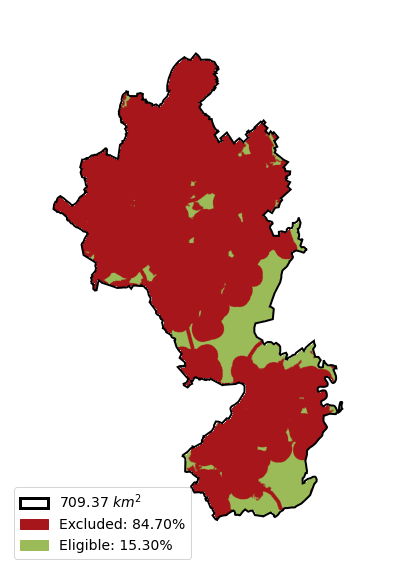

In [ ]:
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

## Apply exclusions from the given set
ec.excludeSet(
    exclusion_set=exclusion_set,
    clc=clc_path,
    osm_roads=r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_roads_free_1.shp",
)

## Draw result
ec.draw()

# Smopy

In [ ]:
import matplotlib.pyplot as plt

<Axes: >

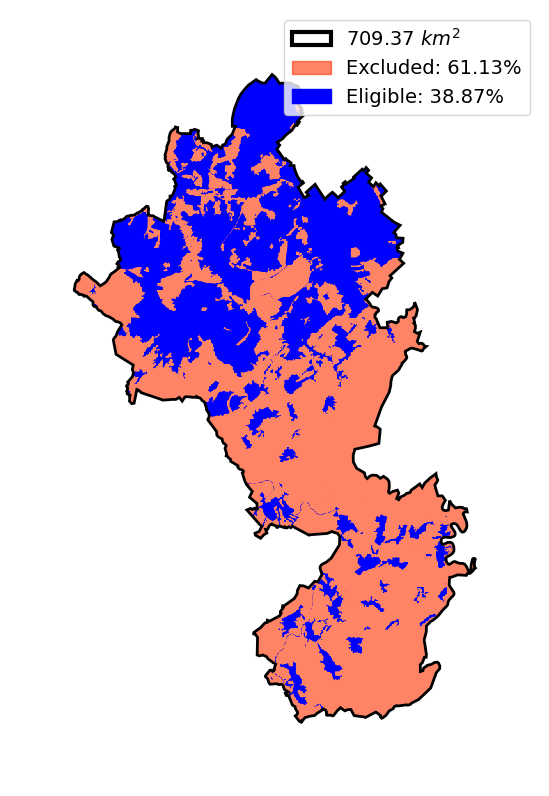

In [ ]:
ec.draw(
    goodColor="blue",
    excludedColor=(1.0, 0.2, 0.0, 0.6),
    legendargs={'loc': 'upper right'},)

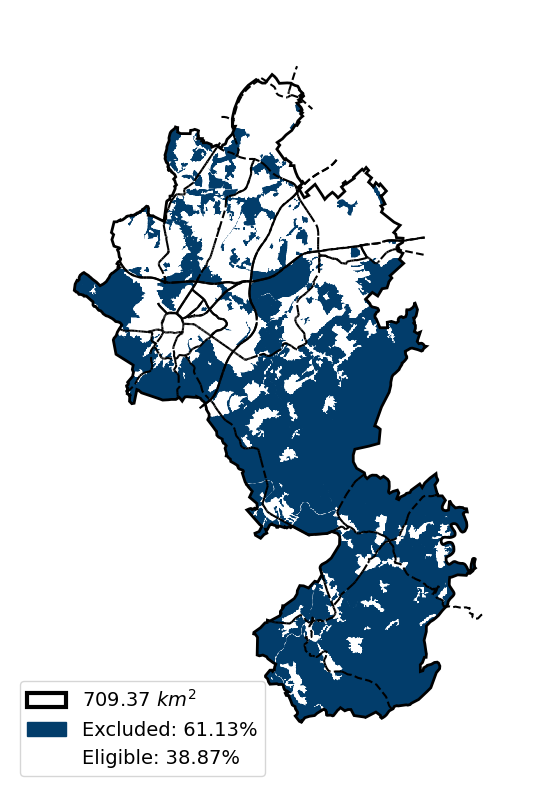

In [ ]:
ax = ec.draw()

# roads = gk.vector.extractFeatures(r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_roads_free_1.shp", 
#                                   where="fclass='motorway' OR fclass='primary' OR fclass='trunk'",
#                                   geom=ec.region.geometry)
# gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=ec.region.srs)

roads = gk.vector.extractFeatures(r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/aachenRoads.shp", 
                                  where="type='motorway' OR type='primary' OR type='trunk'",
                                  geom=ec.region.geometry)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=ec.region.srs)

# gdf = gpd.read_file(r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/aachenRoads.shp")
# print(gdf.columns)
# print(gdf.head(2))

plt.show()

In [ ]:
roads.type.unique()

array(['primary', 'motorway'], dtype=object)

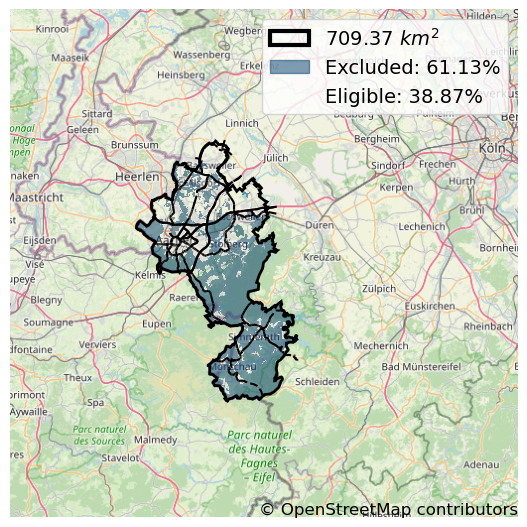

In [ ]:
# Draw with Smopy
## Importance of attribution statement!!

ax = ec.drawWithSmopyBasemap(
    zoom=9,
    legendargs={'loc': 'upper right'},)

roads = gk.vector.extractFeatures(r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/aachenRoads.shp", 
                                  where="type='motorway' OR type='primary' OR type='trunk'",
                                  geom=ec.region.geometry)

gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=gk.srs.EPSG3857)

plt.show()

In [ ]:
ec.drawWithSmopyBasemap?

Signature:
ec.drawWithSmopyBasemap(
    zoom=4,
    excludedColor=(0.6509803921568628, 0.08627450980392157, 0.10196078431372549, 0.5019607843137255),
    ax=None,
    figsize=None,
    smopy_kwargs={'attribution': '© OpenStreetMap contributors', 'attribution_size': 12},
    **kwargs,
)
Docstring:
This wrapper around the original ExclusionCalculator.draw function adds a basemap bethind the drawn eligibility map

NOTE:
* The basemap is drawn using the Smopy python package. See here: https://github.com/rossant/smopy
* Be careful to adhere to the usage guidelines of the chosen tile source
    - By default, this source is OSM. See here: https://wiki.openstreetmap.org/wiki/Tile_servers

!IMPORTANT! If you will publish any images drawn with this method, it's likely that the tile source
will require an attribution to be written on the image. For example, if using OSM tile (the default),
you have to write "© OpenStreetMap contributors" clearly on the map. But this is different for each
tile sou

# Placements

<Axes: >

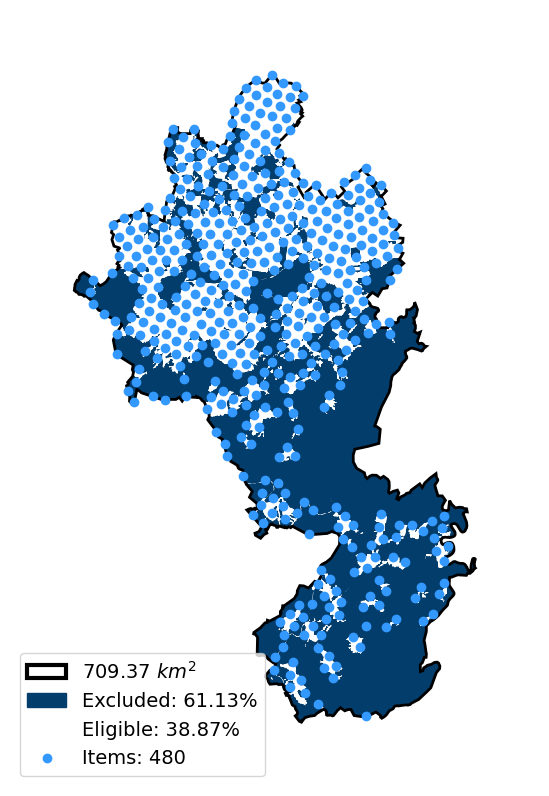

In [32]:
# Placement algorithm - simple separation distance
points = ec.distributeItems( 1000, outputSRS=gk.srs.EPSG4326 )

ec.draw()

In [33]:
ec.itemCoords[:5]

array([[ 6.19423823, 50.95012758],
       [ 6.17645214, 50.94653019],
       [ 6.20704411, 50.94428432],
       [ 6.22091567, 50.94225983],
       [ 6.18836982, 50.94158779]])

<Axes: >

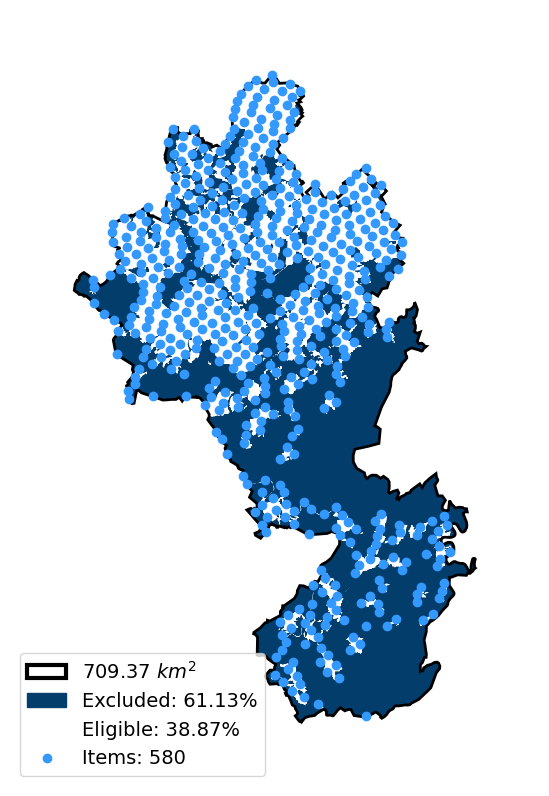

In [34]:
# Placement algorithm - directional separation distance
# East = 0
# North = 90
# West = 180
# South = 270

points = ec.distributeItems( (1400, 600), axialDirection=0, outputSRS=gk.srs.EPSG4326 )

ec.draw()

<Axes: >

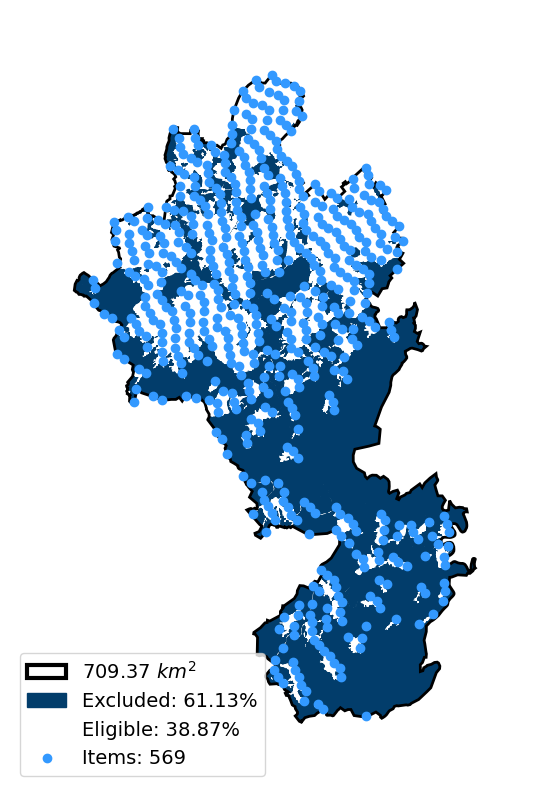

In [35]:
# Placement algorithm - directional separation distance from a raster file
# East = 0
# North = 90
# West = 180
# South = 270

# points = ec.distributeItems( 
#     (1400, 600), 
#     axialDirection="C:/Users/s.ryberg/FZJ/repos/res/reskit/weather/Era5Source/data/ERA5_wind_direction_100m_mean.tiff", 
#     outputSRS=gk.srs.EPSG4326 )

points = ec.distributeItems( 
    (1400, 600), 
    axialDirection=r"data/ERA5_wind_direction_100m_mean.tiff", 
    outputSRS=gk.srs.EPSG4326 )

ec.draw()

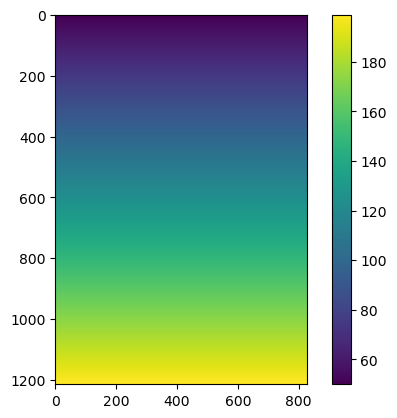

<Axes: >

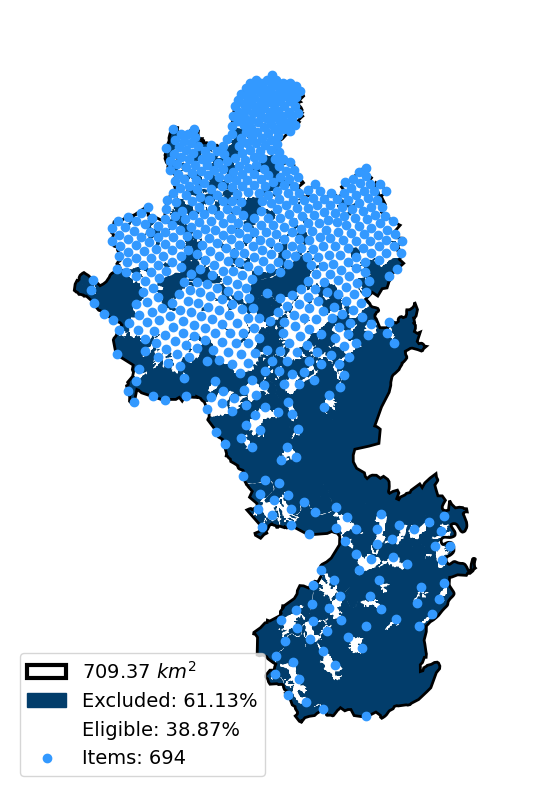

In [36]:
# Placement algorithm - variable separation distance
mat = np.zeros_like(ec.region.mask, dtype=np.uint8)
for i in range(mat.shape[0]):
    mat[i,:] = (200-50)*i/(mat.shape[0]) + 50

h = plt.imshow(mat)
plt.colorbar(h)
plt.show()

rotor_diam_raster = ec.region.createRaster(output="tmp/rotor_diameter.tif", data=mat)

points = ec.distributeItems( 
    separation=8.0,
    sepScaling=rotor_diam_raster)

ec.draw()

<Axes: >

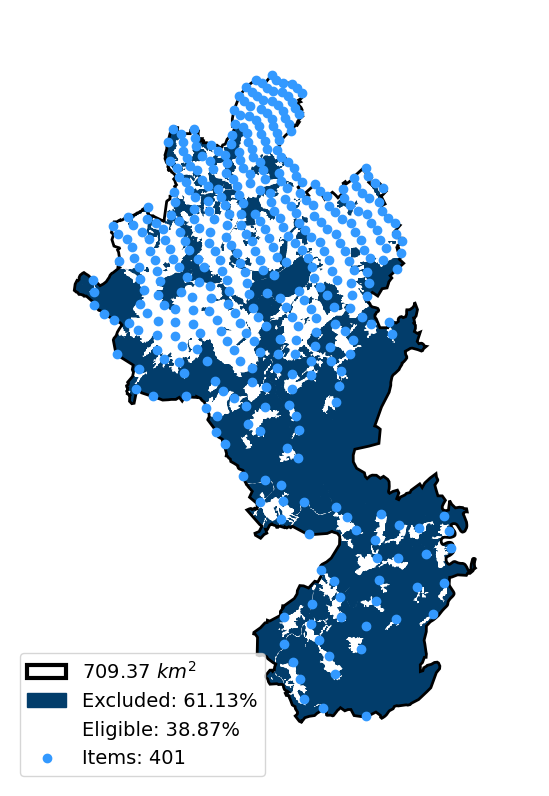

In [37]:
points = ec.distributeItems( 
    separation=(15.0,8.0),
    sepScaling=rotor_diam_raster,
    axialDirection=r"data/ERA5_wind_direction_100m_mean.tiff", 
    outputSRS=gk.srs.EPSG4326 )

ec.draw()

In [38]:
import geokit as gk
import numpy as np

_old_polygon = gk.geom.polygon

def polygon_fix(outerRing, srs=None, *args):
    outerRing = [tuple(p) if isinstance(p, (np.ndarray, list)) else p for p in outerRing]
    return _old_polygon(outerRing, srs=srs, *args)

gk.geom.polygon = polygon_fix

areas = ec.distributeItems(separation=1000, asArea=True, output="placment_areas.shp")

<Axes: >

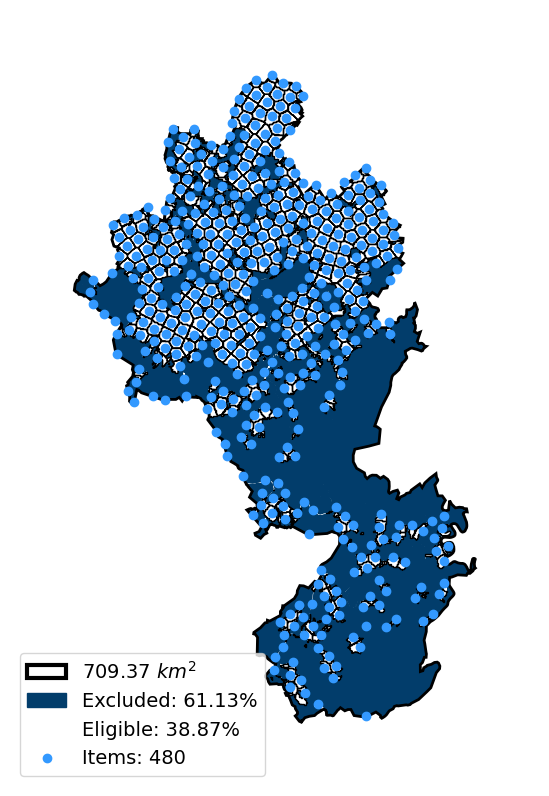

In [39]:
# Placement algorithm - getting areas
ec.save("tmp/placement_exclusion_result.tif")

points = ec.distributeItems(separation=1000, asArea=False, output="tmp/placment_points.shp")

areas = ec.distributeItems( separation=1000, asArea=True, output="placment_areas.shp")

ec.draw()

In [40]:
# extracting info for placements 
points = gk.LocationSet(ec.itemCoords, srs=ec.srs)

mean_wind_speeds = gk.raster.interpolateValues(
    source=r"data/gwa3_250_wind-speed_100m.NRW.tif",
    points=points)


# C:\Users\j.mutke\Desktop\GLAES_Github\glaes\glaes\test\data\ERA5_wind_direction_100m_mean.tiff

# ! geokit raster.warp => global wind atlas (e.g. 3er verions ), fast central shared data
# warp = raster in neuen Kontext überführen, boundaries clippen (eg Aachen latlong), resampling 
# clip a small version to Aachen


dist_from_settlement = gk.raster.interpolateValues(
    source=gl.Priors.settlement_proximity.generateRaster(ec.region.extent),
    points=points)

AttributeError: 'PriorSet' object has no attribute 'settlement_proximity'

In [ ]:
# ! geokit raster.warp => global wind atlas (e.g. 3er verions ), fast central shared data
# warp = raster in neuen Kontext überführen, boundaries clippen (eg Aachen latlong), resampling 
# clip a small version to Aachen

In [48]:
df = pd.DataFrame()
df['geom'] = gk.LocationSet(ec.itemCoords, srs=ec.srs).asGeom()
df['windspeed'] = mean_wind_speeds
df['settledist'] = dist_from_settlement

gk.vector.createVector(df, output="placement_points_with_data.shp")

'placement_points_with_data.shp'

In [49]:
df

,geom,windspeed,settledist
0,POINT (6.08760705339576 50.9096257544788 0),7.391802,1050.0
1,POINT (6.07838602738474 50.9015265947583 0),6.976899,1250.0
2,POINT (6.30081550772289 50.8831130974103 0),7.321034,1050.0
3,POINT (6.30434424452087 50.8727724170833 0),7.424338,1350.0
4,POINT (6.31373924191766 50.866021674016 0),7.055402,1450.0
...,...,...,...
194,POINT (6.30104393494824 50.5055588713916 0),7.601233,3250.0
195,POINT (6.32376566345361 50.5023899917281 0),7.673443,4750.0
196,POINT (6.29045936075381 50.4992750769464 0),7.523646,3250.0
197,POINT (6.23936737194443 50.4993047457608 0),7.862500,1050.0


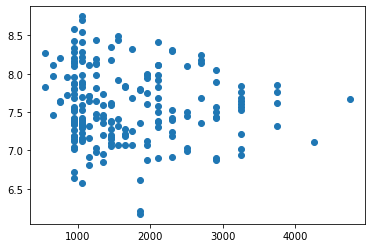

In [46]:
# plot settlement distance vs wind speed
plt.scatter(df['settledist'],df['windspeed'])
plt.show()

In [135]:
areas = ec.distributeItems( separation=1000, asArea=True)
areas

[<osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139FABD50> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139F981E0> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AA9CEA0> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139FAB150> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AAA1B70> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AAA2300> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139FAB030> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AA9EC90> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AA9EF90> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AAB9300> >,
